## Setup

In [104]:
from os import path
import rasterio
import numpy as np
import glob
import os
import torch
from torchgeo.models import croma_base, CROMABase_Weights

PATCH_SIZE = 8
EMBED_DIM = 768
TILE_SIZE = 120
GRID_SIZE = TILE_SIZE // PATCH_SIZE     # 15

device = torch.device("cpu")
print(f"Device: {device}")

def load_tile(path, band_indices=None):
    with rasterio.open(path) as src:
        if band_indices is None:
            data = src.read().astype(np.float32)
        else:
            data = src.read([i + 1 for i in band_indices]).astype(np.float32)
    return data

folder = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval"

Device: cpu


## Upload the tiles

In [105]:
#just optical
tif_files = sorted(glob.glob(os.path.join(folder, "s2_*.tif")))

tiles = {}
for f in tif_files:
    name = os.path.basename(f)
    tiles[name] = load_tile(f)

In [106]:
# check max and min of the optical tiles
for name, tile in tiles.items():
    print(f"Tile {name} has max value {tile.max()} and min value {tile.min()}")


Tile s2_loc1_0_10.tif has max value 4902.0 and min value 102.0
Tile s2_loc1_10_20.tif has max value 5957.0 and min value 93.0
Tile s2_loc1_20_30.tif has max value 5444.0 and min value 220.0


## Visualization of the tiles

In [107]:
import rasterio

path_tile = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tropical_forest_disturbance/data_img/croma_cloud_eval/s2_loc1_0_10.tif"

with rasterio.open(path_tile) as src:
    print(f"Number of bands: {src.count}")
    print(f"Dimensions (height x width): {src.height} x {src.width}")
    print(f"Resolution (x, y): {src.res}")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")
    print(f"Data types by band: {src.dtypes}")
    print(f"Band names/descriptions: {src.descriptions}")

Number of bands: 12
Dimensions (height x width): 120 x 120
Resolution (x, y): (9.95908995376473, 9.951647785802683)
CRS: EPSG:32720
Transform: | 9.96, 0.00, 666247.15|
| 0.00,-9.95, 8622735.44|
| 0.00, 0.00, 1.00|
Data types by band: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
Band names/descriptions: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')


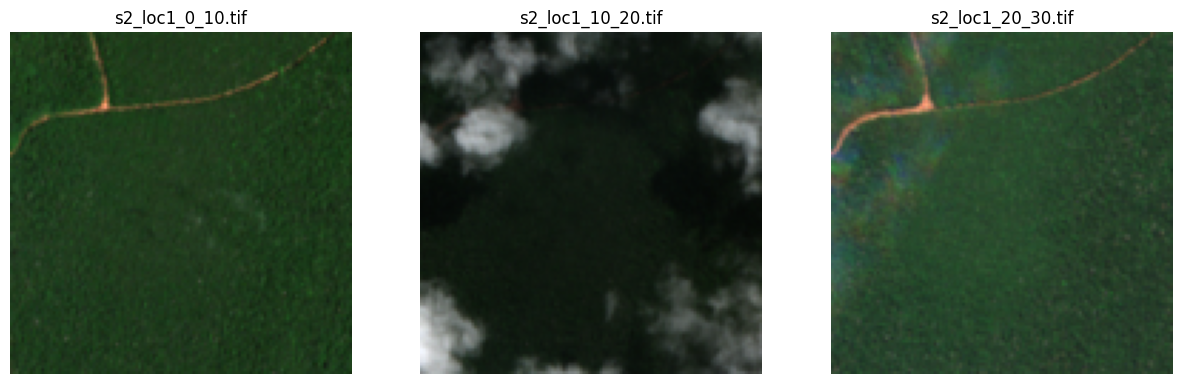

In [108]:
import math
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, tile) in zip(axes, tiles.items()):
    rgb = tile[[3, 2, 1]].transpose(1, 2, 0) #  b4, b3, b2 in the format (H, W, 3)
    rgb = rgb / rgb.max()                     # normalizar a 0-1
    ax.imshow(rgb)
    ax.set_title(name)
    ax.axis("off")

plt.show()

## Global stats

In [109]:
def compute_global_stats(folder, band_indices=None, min_valid=None, max_valid=None, pattern="s2_*.tif"):
    paths = sorted(glob.glob(os.path.join(folder, pattern)))
    if not paths:
        raise FileNotFoundError(f"No tiles found in: {folder} with pattern {pattern}")

    if band_indices is None:
        with rasterio.open(paths[0]) as src:
            band_indices = list(range(src.count))

    C = len(band_indices)
    sum_   = np.zeros(C, dtype=np.float64)
    sum_sq = np.zeros(C, dtype=np.float64)
    count  = np.zeros(C, dtype=np.int64)

    for p in paths:
        data = load_tile(p, band_indices=band_indices)
        valid = np.isfinite(data)
        if min_valid is not None:
            valid &= (data > min_valid)
        if max_valid is not None:
            valid &= (data < max_valid)

        d = np.where(valid, data, 0.0).astype(np.float64)
        sum_   += d.sum(axis=(1, 2))
        sum_sq += (d * d).sum(axis=(1, 2))
        count  += valid.sum(axis=(1, 2)).astype(np.int64)

    mean = sum_ / np.maximum(count, 1)
    var  = sum_sq / np.maximum(count, 1) - mean ** 2
    std  = np.sqrt(np.maximum(var, 0.0))
    return mean.astype(np.float32), std.astype(np.float32), len(paths)

In [110]:
band_indices = list(range(12))   # B1..B12 (sin B10)
band_names   = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12"]

mean, std, n_tiles = compute_global_stats(
    folder,
    band_indices=band_indices,
    min_valid=0       # descarta píxeles negativos / no-data
)

print(f"Tiles procesados: {n_tiles}")
for i, b in enumerate(band_names):
    print(f"{b}: mean={mean[i]:.2f}  std={std[i]:.2f}")

Tiles procesados: 3
B1: mean=432.24  std=374.04
B2: mean=389.41  std=408.26
B3: mean=567.08  std=380.93
B4: mean=382.74  std=396.18
B5: mean=917.07  std=403.13
B6: mean=2425.50  std=508.17
B7: mean=2966.11  std=588.44
B8: mean=2918.45  std=623.19
B8A: mean=3292.93  std=626.90
B9: mean=3318.69  std=665.68
B11: mean=1798.72  std=423.28
B12: mean=819.13  std=418.85


## Normalize

In [111]:
def normalize(x, mean, std):
    """CROMA recipe with global stats: clip to mean ± 2*std per channel, rescale to [0, 1].

    x:    (N, C, H, W) tensor
    mean: (C,) tensor or array
    std:  (C,) tensor or array
    """
    x = x.float()
    mean = torch.as_tensor(mean, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    std = torch.as_tensor(std, dtype=x.dtype, device=x.device).view(1, -1, 1, 1)
    min_val = mean - 2 * std
    max_val = mean + 2 * std
    x = (x - min_val) / (max_val - min_val)
    return torch.clamp(x, 0, 1)

## Encoder helper

In [112]:
def encode(model, x_normalized, modality):
    """Forward pass on a normalized batch. Returns (N, 15, 15, 768) tokens."""
    captured = {}
    encoder = model.s2_encoder if modality == "optical" else model.s1_encoder

    def hook(module, inp, out):
        captured["tokens"] = out

    h = encoder.register_forward_hook(hook)
    with torch.no_grad():
        if modality == "optical":
            _ = model(x_optical=x_normalized)
        else:
            _ = model(x_sar=x_normalized)
    h.remove()

    out = captured["tokens"]
    if isinstance(out, tuple):
        out = out[0]
    tokens = out.cpu().numpy()
    if tokens.ndim == 2:
        tokens = tokens[None]
    expected = GRID_SIZE * GRID_SIZE
    if tokens.shape[1] == expected + 1:
        tokens = tokens[:, 1:]
    return tokens.reshape(-1, GRID_SIZE, GRID_SIZE, EMBED_DIM)

## Load CROMA models

In [113]:
model = croma_base(
    weights=CROMABase_Weights.CROMA_VIT,
    modalities=["optical"],
    image_size=120,
).to(device).eval()
print("CROMA optical model loaded")

CROMA optical model loaded


In [114]:
from torchgeo.models import croma_base, CROMABase_Weights

model_joint = croma_base(
    weights     = CROMABase_Weights.CROMA_VIT,
    modalities  = ["sar", "optical"],
    image_size  = 120,
).to(device).eval()
print("CROMA joint model loaded.")

CROMA joint model loaded.


## Creation of the embeddings

### Creation of the tensor with the data

In [115]:
MODALITY = "optical"  

# 1) Build (N, 12, 120, 120) tensor
all_data = np.stack(list(tiles.values()), axis=0).astype(np.float32)
tile_names = list(tiles.keys())
print(f"Input shape: {all_data.shape}, order: {tile_names}")

# 2) Normalize + encode (usando mean/std globales ya calculados)
x = torch.from_numpy(all_data)
x = normalize(x, mean, std).to(device)
tokens = encode(model, x, MODALITY)          # (N, 15, 15, 768)
print(f"Tokens shape: {tokens.shape}")

Input shape: (3, 12, 120, 120), order: ['s2_loc1_0_10.tif', 's2_loc1_10_20.tif', 's2_loc1_20_30.tif']
Tokens shape: (3, 15, 15, 768)
